Random Forest Model


=== 30-Day Readmission ===
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      2022
           1       0.85      0.82      0.84      2063

    accuracy                           0.84      4085
   macro avg       0.84      0.84      0.84      4085
weighted avg       0.84      0.84      0.84      4085

ROC AUC Score: 0.9193


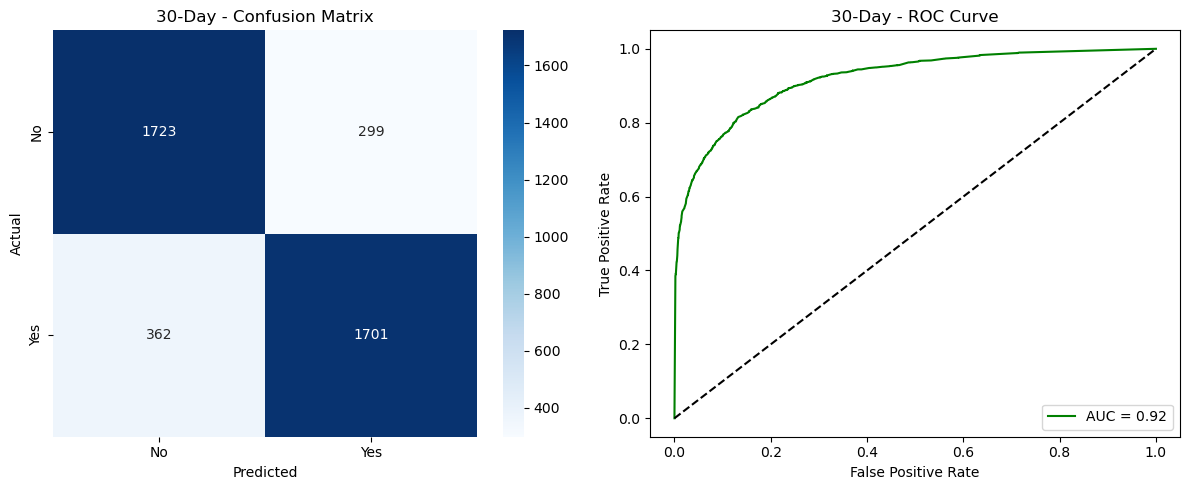


=== 60-Day Readmission ===
              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1857
           1       0.85      0.83      0.84      2228

    accuracy                           0.83      4085
   macro avg       0.82      0.83      0.83      4085
weighted avg       0.83      0.83      0.83      4085

ROC AUC Score: 0.9112


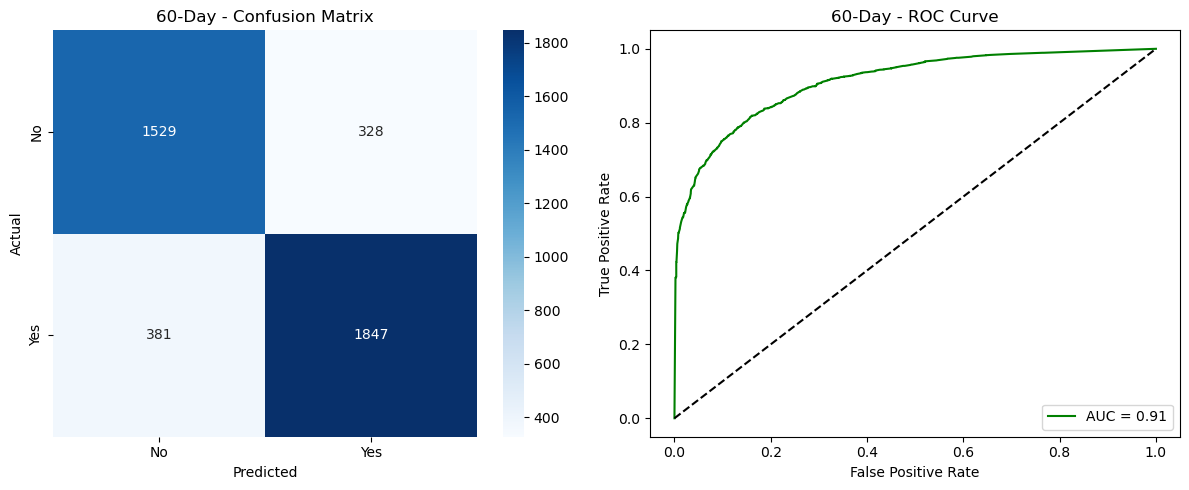

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

# Load dataset
df = pd.read_csv("readmission_dataset.csv")

# Shared features (exclude targets)
features = df.columns.difference(["readmitted_30_days", "readmitted_60_days"])

# Normalize numeric features
numeric_cols = df[features].select_dtypes(include=["float64", "int64"]).columns
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

# Function to train, evaluate, and visualize
def train_and_evaluate(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {label} Readmission ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"{label} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}", color="green")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{label} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# Train and evaluate both models
X_all = df[features]
train_and_evaluate(X_all, df["readmitted_30_days"], "30-Day")
train_and_evaluate(X_all, df["readmitted_60_days"], "60-Day")


Logistic Regression Model

/var/folders/d4/n8k1334n6v910lgvrxcfdjfw0000gn/T/ipykernel_4361/2624785683.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[numeric_cols] = scaler.fit_transform(X[numeric_cols])



=== 30-Day Readmission ===
              precision    recall  f1-score   support

           0       0.80      0.73      0.76      2022
           1       0.76      0.82      0.79      2063

    accuracy                           0.78      4085
   macro avg       0.78      0.78      0.78      4085
weighted avg       0.78      0.78      0.78      4085

ROC AUC Score: 0.8481


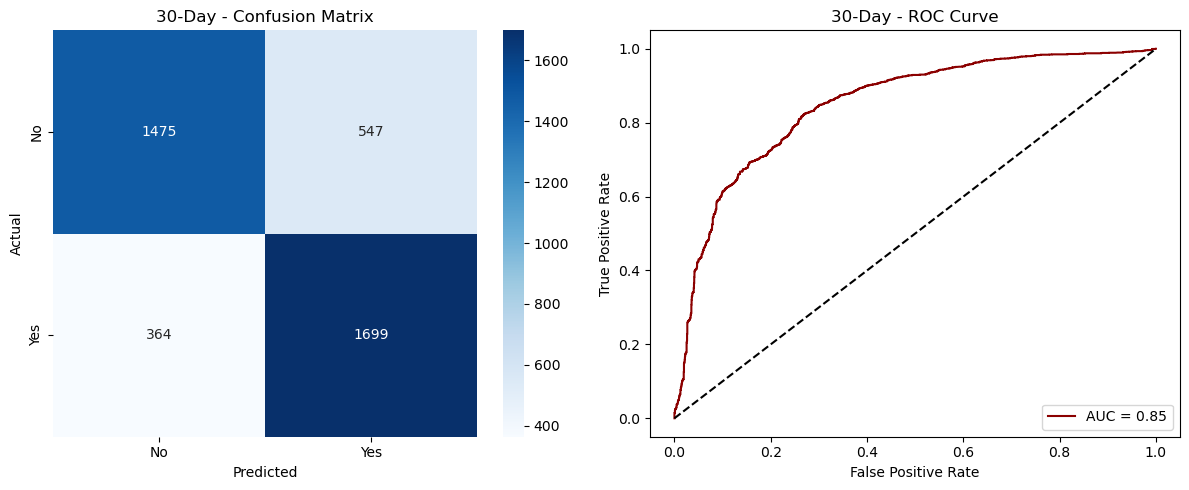


=== 60-Day Readmission ===
              precision    recall  f1-score   support

           0       0.77      0.75      0.76      1857
           1       0.80      0.82      0.81      2228

    accuracy                           0.79      4085
   macro avg       0.78      0.78      0.78      4085
weighted avg       0.79      0.79      0.79      4085

ROC AUC Score: 0.8509


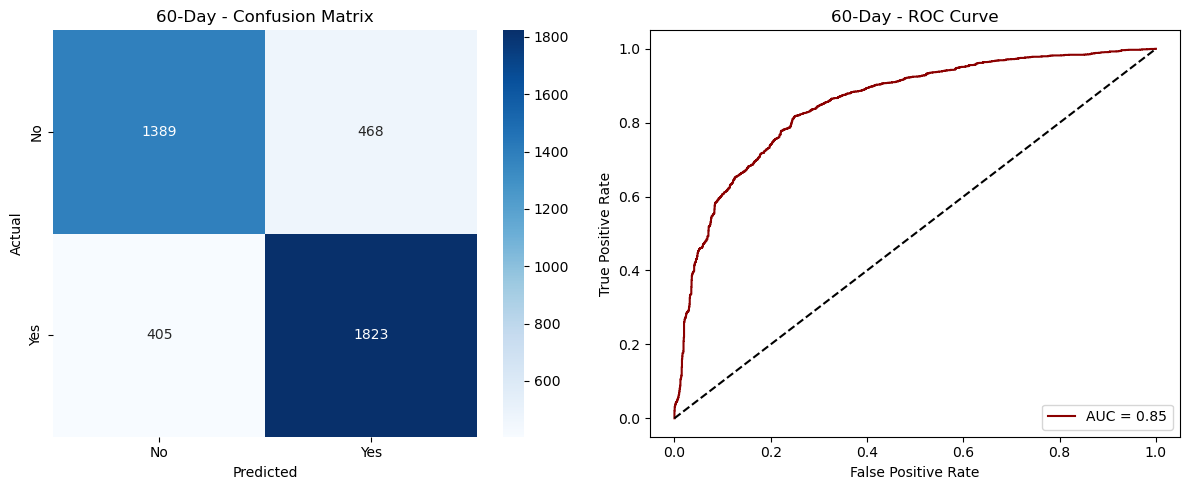

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

# --- Load Dataset ---
df = pd.read_csv("readmission_dataset.csv")

# --- Define features and targets ---
features = df.columns.difference(["readmitted_30_days", "readmitted_60_days"])
X = df[features]
y_30 = df["readmitted_30_days"]
y_60 = df["readmitted_60_days"]

# --- Normalize numeric features ---
numeric_cols = X.select_dtypes(include=["float64", "int64"]).columns
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# --- Function to train, evaluate, and visualize ---
def train_and_visualize_lr(X, y, label):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    print(f"\n=== {label} Readmission ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba):.4f}")

    # Confusion Matrix + ROC
    cm = confusion_matrix(y_test, y_pred)
    fpr, tpr, _ = roc_curve(y_test, y_proba)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["No", "Yes"], yticklabels=["No", "Yes"])
    plt.title(f"{label} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.subplot(1, 2, 2)
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}", color="darkred")
    plt.plot([0, 1], [0, 1], "k--")
    plt.title(f"{label} - ROC Curve")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend(loc="lower right")

    plt.tight_layout()
    plt.show()

# --- Train and evaluate both models ---
train_and_visualize_lr(X, y_30, "30-Day")
train_and_visualize_lr(X, y_60, "60-Day")
